<a href="https://colab.research.google.com/github/Mateo0o0o0ocf/mineria_de_datos/blob/main/Entrega_3_mineria_de_datos.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

*Link* de descarga del dataset: "
https://www.kaggle.com/datasets/sidtwr/videogames-sales-dataset"

# Entrega 3 — Minería de Datos
**Dataset:** Video Games Sales (Kaggle)  
**Integrantes:** Mateo Carrasco, Adolfo Cartes  


## Introducción del Negocio

La industria de los videojuegos es uno de los mercados de entretenimiento más grandes y dinámicos del mundo. Con miles de títulos lanzados cada año en múltiples plataformas (consolas, PC, portátiles), comprender qué factores determinan el éxito comercial de un videojuego es fundamental para editores, desarrolladores e inversores.

**Objetivo del análisis:** Explorar el dataset de ventas de videojuegos (1980–2016) para identificar patrones de ventas globales y regionales, entender la relación entre las puntuaciones de crítica/usuarios y el rendimiento comercial, y construir modelos predictivos que permitan estimar si un juego alcanzará ventas globales altas.

**Dataset:** Contiene información de **16.719 videojuegos**, incluyendo nombre, plataforma, año de lanzamiento, género, publisher, ventas por región (Norteamérica, Europa, Japón y Otros), puntuaciones de críticos y usuarios, y clasificación de edad (Rating ESRB).

**Fuente:** [Kaggle – Video Games Sales Dataset](https://www.kaggle.com/datasets/sidtwr/videogames-sales-dataset)

## Importaciones y carga de datos

In [ ]:
# Librerías utilizadas
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
# Carga del dataset
df = pd.read_csv('/content/Video_Games_Sales_as_at_22_Dec_2016.csv')
df.head()

,Name,Platform,Year_of_Release,Genre,Publisher,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales,Critic_Score,Critic_Count,User_Score,User_Count,Developer,Rating
0,Wii Sports,Wii,2006.0,Sports,Nintendo,41.36,28.96,3.77,8.45,82.53,76.0,51.0,8.0,322.0,Nintendo,E
1,Super Mario Bros.,NES,1985.0,Platform,Nintendo,29.08,3.58,6.81,0.77,40.24,NaN,NaN,NaN,NaN,NaN,NaN
2,Mario Kart Wii,Wii,2008.0,Racing,Nintendo,15.68,12.76,3.79,3.29,35.52,82.0,73.0,8.3,709.0,Nintendo,E
3,Wii Sports Resort,Wii,2009.0,Sports,Nintendo,15.61,10.93,3.28,2.95,32.77,80.0,73.0,8.0,192.0,Nintendo,E
4,Pokemon Red/Pokemon Blue,GB,1996.0,Role-Playing,Nintendo,11.27,8.89,10.22,1.00,31.37,NaN,NaN,NaN,NaN,NaN,NaN


---
## Analisis exploratotio(EDA)

In [ ]:
df.shape #devuelve la cantidad de filas y columnas respectivamente

(16719, 16)

In [ ]:
df.dtypes #observamos la columna y sus tipos de datos

,0
Name,object
Platform,object
Year_of_Release,float64
Genre,object
Publisher,object
NA_Sales,float64
EU_Sales,float64
JP_Sales,float64
Other_Sales,float64
Global_Sales,float64


In [ ]:
df.isnull().sum() #contamos la cantidad de nulos por columna

,0
Name,2
Platform,0
Year_of_Release,269
Genre,2
Publisher,54
NA_Sales,0
EU_Sales,0
JP_Sales,0
Other_Sales,0
Global_Sales,0


In [ ]:
tipos = df.columns.to_series().groupby(df.dtypes).groups
# Conociendo la lista de columnas categóricas
ctext = tipos[np.dtype('object')]
len(ctext) # cantidad de columnas con datos categóricos.

6

In [ ]:
 # Conociendo la lista de columnas numéricas
columnas = df.columns
cnum = list(set(columnas) - set(ctext))
len(cnum)


10

In [ ]:
#Se tratan los nulos para las variables numericas

for columna in cnum:
    mediana = df[columna].median()
    df[columna] = df[columna].fillna(mediana)


In [ ]:
#Se tratan los nulos para las variables categoricas

for columna in ctext:
    df[columna] = df[columna].fillna("Desconocido")

In [ ]:
df.isnull().sum() #contamos la cantidad de nulos por columna

,0
Name,0
Platform,0
Year_of_Release,0
Genre,0
Publisher,0
NA_Sales,0
EU_Sales,0
JP_Sales,0
Other_Sales,0
Global_Sales,0


In [ ]:
df.columns #mostramos los nombres de las columnas

Index(['Name', 'Platform', 'Year_of_Release', 'Genre', 'Publisher', 'NA_Sales',
       'EU_Sales', 'JP_Sales', 'Other_Sales', 'Global_Sales', 'Critic_Score',
       'Critic_Count', 'User_Score', 'User_Count', 'Developer', 'Rating'],
      dtype='object')


| Columna | Descripción | Tipo |
|---|---|---|
| `Name` | Nombre del videojuego | Categórico Nominal |
| `Platform` | Plataforma de lanzamiento (PS2, Wii, X360, etc.) | Categórico Nominal |
| `Year_of_Release` | Año en que fue lanzado el juego | Numérico Discreto |
| `Genre` | Género del juego (Action, Sports, RPG, etc.) | Categórico Nominal |
| `Publisher` | Empresa que publicó el juego | Categórico Nominal |
| `NA_Sales` | Ventas en Norteamérica (millones de unidades) | Numérico Continuo |
| `EU_Sales` | Ventas en Europa (millones de unidades) | Numérico Continuo |
| `JP_Sales` | Ventas en Japón (millones de unidades) | Numérico Continuo |
| `Other_Sales` | Ventas en el resto del mundo (millones de unidades) | Numérico Continuo |
| `Global_Sales` | Ventas globales totales (millones de unidades) | Numérico Continuo |
| `Critic_Score` | Puntaje promedio de críticos profesionales (0–100) | Numérico Discreto |
| `Critic_Count` | Número de críticos que evaluaron el juego | Numérico Discreto |
| `User_Score` | Puntaje promedio de usuarios (0–10) | Numérico Continuo |
| `User_Count` | Número de usuarios que evaluaron el juego | Numérico Discreto |
| `Developer` | Empresa que desarrolló el juego | Categórico Nominal |
| `Rating` | Clasificación de edad ESRB (E, T, M, etc.) | Categórico Nominal |

MAPEO DE DATOS

*   Name: Categórico Nominal
*   Platform: Categórico Nominal
*   Year_of_Release: Numérico Discreto
*   Genre: Categórico Nominal
*   Publisher: Categórico Nominal
*   NA_Sales: Numérico Continuo
*   EU_Sales: Numérico Continuo
*   JP_Sales: Numérico Continuo
*   Other_Sales: Numérico Continuo
*   Global_Sales: Numérico Continuo
*   Critic_Score: Numérico Discreto
*   Critic_Count: Numérico Discreto
*   User_Score: Numérico Continuo
*   User_Count: Numérico Discreto
*   Developer: Categórico Nominal
*   Rating: Categórico Nominal




In [ ]:
cant_cat_name_plat_df = df['Name'].value_counts()#nos mostrará la cantidad de categoricas distintas unicas de nombe
print(cant_cat_name_plat_df)

print(f"cantidad de nombes: {cant_cat_name_plat_df.count()}")

Name
Need for Speed: Most Wanted      12
Ratatouille                       9
LEGO Marvel Super Heroes          9
Madden NFL 07                     9
FIFA 14                           9
                                 ..
Outdoors Unleashed: Africa 3D     1
Real Rode                         1
PGA European Tour                 1
Duck Hunt                         1
New Super Mario Bros. Wii         1
Name: count, Length: 11563, dtype: int64
cantidad de nombes: 11563


In [ ]:
cant_cat_col_plat_df = df['Platform'].value_counts()#nos mostrará la cantidad de categoricas distintas unicas de gategorias
print(cant_cat_col_plat_df)

print(f"cantidad de plataformas: {cant_cat_col_plat_df.count()}")

Platform
PS2     2161
DS      2152
PS3     1331
Wii     1320
X360    1262
PSP     1209
PS      1197
PC       974
XB       824
GBA      822
GC       556
3DS      520
PSV      432
PS4      393
N64      319
XOne     247
SNES     239
SAT      173
WiiU     147
2600     133
NES       98
GB        98
DC        52
GEN       29
NG        12
SCD        6
WS         6
3DO        3
TG16       2
GG         1
PCFX       1
Name: count, dtype: int64
cantidad de plataformas: 31


In [ ]:
cant_cat_genre_plat_df = df['Genre'].value_counts()#nos mostrará la cantidad de categoricas distintas unicas de Genero
print(cant_cat_genre_plat_df)

print(f"cantidad de generos: {cant_cat_genre_plat_df.count()}")

Genre
Action          3370
Sports          2348
Misc            1750
Role-Playing    1500
Shooter         1323
Adventure       1303
Racing          1249
Platform         888
Simulation       874
Fighting         849
Strategy         683
Puzzle           580
Desconocido        2
Name: count, dtype: int64
cantidad de generos: 13


In [ ]:
cant_cat_publi_plat_df = df['Publisher'].value_counts()#nos mostrará la cantidad de categoricas distintas unicas de Publicadores
print(cant_cat_publi_plat_df)

print(f"cantidad de publicadores: {cant_cat_publi_plat_df.count()}")

Publisher
Electronic Arts                 1356
Activision                       985
Namco Bandai Games               939
Ubisoft                          933
Konami Digital Entertainment     834
                                ... 
Commseed                           1
UIG Entertainment                  1
Mirai Shounen                      1
Imageworks                         1
Karin Entertainment                1
Name: count, Length: 583, dtype: int64
cantidad de publicadores: 583


In [ ]:
cant_cat_dev_plat_df = df['Developer'].value_counts()#nos mostrará la cantidad de categoricas distintas unicas de Developers
print(cant_cat_dev_plat_df)

print(f"cantidad de desarolladores: {cant_cat_dev_plat_df.count()}")

Developer
Desconocido                            6623
Ubisoft                                 204
EA Sports                               172
EA Canada                               167
Konami                                  162
                                       ... 
Camouflaj, LLC                            1
Compulsion Games                          1
Inferno Games                             1
Papyrus                                   1
Bigben Interactive, Red Wagon Games       1
Name: count, Length: 1697, dtype: int64
cantidad de desarolladores: 1697


In [ ]:
cant_cat_rating_plat_df = df['Rating'].value_counts()#nos mostrará la cantidad de categoricas distintas unicas de Rating
print(cant_cat_rating_plat_df)

print(f"cantidad de Ratings: {cant_cat_rating_plat_df.count()}")

Rating
Desconocido    6769
E              3991
T              2961
M              1563
E10+           1420
EC                8
K-A               3
RP                3
AO                1
Name: count, dtype: int64
cantidad de Ratings: 9


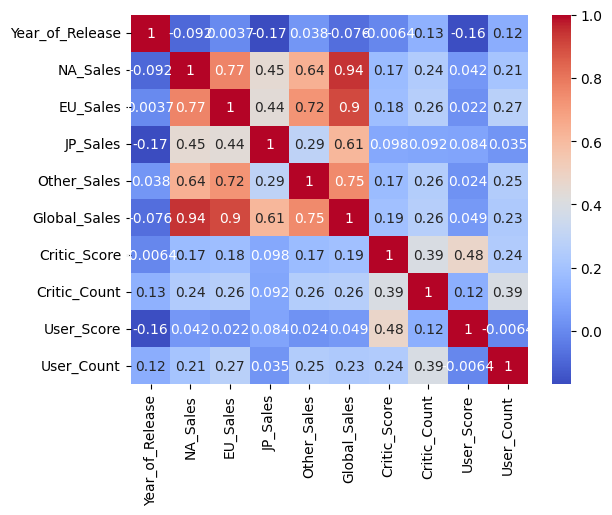

In [ ]:
corr = df.select_dtypes(include='number').corr()
#corr_ejem2 = df.corr()

sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.show()

### Interpretación de la Matriz de Correlación

La matriz de correlación permite identificar qué variables numéricas están relacionadas entre sí:

- **Ventas regionales vs. Global_Sales:** Las correlaciones más altas se observan entre `NA_Sales`, `EU_Sales`, `JP_Sales`, `Other_Sales` y `Global_Sales` (esperado, ya que las ventas globales son la suma de las regionales).
- **Critic_Score vs. Ventas:** Existe una correlación positiva moderada entre el puntaje de críticos y las ventas globales, lo que sugiere que los juegos mejor evaluados tienden a vender más.
- **User_Score vs. Critic_Score:** Correlación positiva leve; usuarios y críticos coinciden parcialmente en sus valoraciones.
- **Critic_Count / User_Count:** Tienden a correlacionar positivamente con las ventas, ya que los juegos más vendidos reciben más atención y reseñas.
- **Year_of_Release:** Correlación débil con ventas, indicando que el año de lanzamiento no es un predictor directo del éxito comercial.

> **Conclusión clave:** Los scores de críticos son los predictores numéricos más relevantes para las ventas globales, junto con las ventas regionales.

---
## Preprocesamiento

In [ ]:
# Separamos columnas numéricas y categóricas
tipos = df.columns.to_series().groupby(df.dtypes).groups
ctext = tipos[np.dtype('object')]          # columnas de texto
cnum  = list(set(df.columns) - set(ctext)) # columnas numéricas

In [ ]:
# Rellenamos nulos:
# - numéricas con la mediana (más robusta que la media ante valores extremos)
# - categóricas con 'Desconocido'
for col in cnum:
    df[col] = df[col].fillna(df[col].median())

for col in ctext:
    df[col] = df[col].fillna('Desconocido')

print('Nulos restantes:', df.isnull().sum().sum())

Nulos restantes: 0


In [ ]:
# Convertimos columnas numéricas a sus tipos correctos
cols_numericas = ['Year_of_Release','NA_Sales','EU_Sales','JP_Sales',
                  'Other_Sales','Global_Sales','Critic_Score',
                  'Critic_Count','User_Score','User_Count']

for col in cols_numericas:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col].astype(str).str.strip(), errors='coerce')

# Enteros para columnas que no deben tener decimales
for col in ['Year_of_Release','Critic_Score','Critic_Count','User_Count']:
    if col in df.columns:
        df[col] = df[col].astype('Int64')

df.dtypes

,0
Name,object
Platform,object
Year_of_Release,Int64
Genre,object
Publisher,object
NA_Sales,float64
EU_Sales,float64
JP_Sales,float64
Other_Sales,float64
Global_Sales,float64


In [ ]:
# Instalamos el encoder para variables categóricas de alta cardinalidad
!pip install category_encoders -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 85.9/85.9 kB 2.3 MB/s eta 0:00:00


In [ ]:
from sklearn.preprocessing import OneHotEncoder
import category_encoders as ce

# One-Hot para columnas con pocos valores únicos
cols_ohe    = ['Platform', 'Genre', 'Rating']
# Binary Encoding para columnas con muchos valores únicos (Publisher, Developer)
cols_binary = ['Publisher', 'Developer']

ohe = OneHotEncoder(sparse_output=False)
ohe_encoded = ohe.fit_transform(df[cols_ohe])
ohe_df = pd.DataFrame(ohe_encoded,
                      columns=ohe.get_feature_names_out(cols_ohe),
                      index=df.index)

be = ce.BinaryEncoder(cols=cols_binary)
df_binary = be.fit_transform(df[cols_binary])

# DataFrame final con todas las variables codificadas
df_final = pd.concat([
    df.drop(columns=cols_ohe + cols_binary + ['Name']),
    ohe_df,
    df_binary
], axis=1)

print(f'Columnas totales tras encoding: {len(df_final.columns)}')
df_final.head()

Columnas totales tras encoding: 84


,Year_of_Release,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales,Critic_Score,Critic_Count,User_Score,User_Count,...,Developer_1,Developer_2,Developer_3,Developer_4,Developer_5,Developer_6,Developer_7,Developer_8,Developer_9,Developer_10
0,2006,41.36,28.96,3.77,8.45,82.53,76,51,8.0,322,...,0,0,0,0,0,0,0,0,0,1
1,1985,29.08,3.58,6.81,0.77,40.24,71,21,7.5,24,...,0,0,0,0,0,0,0,0,1,0
2,2008,15.68,12.76,3.79,3.29,35.52,82,73,8.3,709,...,0,0,0,0,0,0,0,0,0,1
3,2009,15.61,10.93,3.28,2.95,32.77,80,73,8.0,192,...,0,0,0,0,0,0,0,0,0,1
4,1996,11.27,8.89,10.22,1.00,31.37,71,21,7.5,24,...,0,0,0,0,0,0,0,0,1,0


---
## Modelo 1 — Ridge Regression
**Objetivo:** Predecir `Global_Sales` (ventas globales en millones).  
**Por qué Ridge:** Agrega regularización L2 para evitar overfitting cuando hay variables correlacionadas.

In [ ]:
# --- PREPARACIÓN DE DATOS ---
# Excluimos ventas regionales para evitar data leakage
# (Global_Sales es la suma de las regionales, el modelo aprendería a sumar, no a predecir)
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

features_reg = ['Critic_Score', 'User_Score', 'Critic_Count', 'User_Count', 'Year_of_Release']
target_reg   = 'Global_Sales'

df_model = df[features_reg + [target_reg]].dropna()

X_reg = df_model[features_reg]
y_reg = df_model[target_reg]

# 80% entrenamiento, 20% prueba
X_train, X_test, y_train, y_test = train_test_split(X_reg, y_reg, test_size=0.2, random_state=42)

# Escalamos para que Ridge funcione correctamente
scaler     = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

print(f'Tamaño entrenamiento: {X_train_sc.shape}')
print(f'Tamaño prueba:        {X_test_sc.shape}')

Tamaño entrenamiento: (13375, 5)
Tamaño prueba:        (3344, 5)


In [ ]:
# --- ENTRENAMIENTO ---
from sklearn.linear_model import Ridge

ridge = Ridge(alpha=1.0)  # alpha controla la fuerza de la regularización
ridge.fit(X_train_sc, y_train)
y_pred_ridge = ridge.predict(X_test_sc)

print('Modelo Ridge entrenado correctamente.')

Modelo Ridge entrenado correctamente.


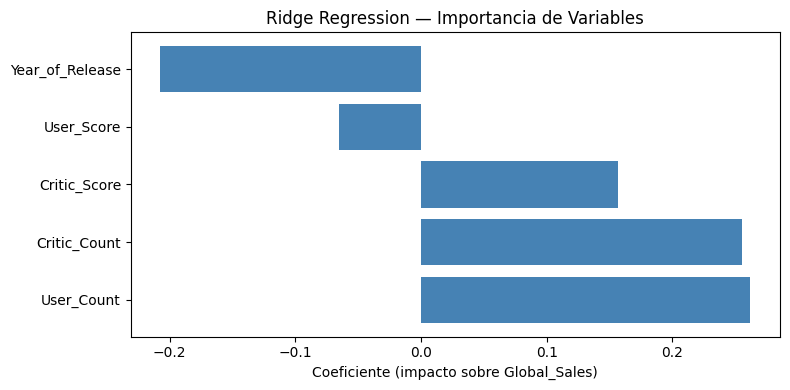

In [ ]:
# --- IMPORTANCIA DE VARIABLES ---
# El coeficiente indica cuánto impacta cada variable en las ventas globales
coef_df = pd.DataFrame({'Feature': features_reg, 'Coeficiente': ridge.coef_})
coef_df = coef_df.sort_values('Coeficiente', ascending=False)

plt.figure(figsize=(8, 4))
plt.barh(coef_df['Feature'], coef_df['Coeficiente'], color='steelblue')
plt.xlabel('Coeficiente (impacto sobre Global_Sales)')
plt.title('Ridge Regression — Importancia de Variables')
plt.tight_layout()
plt.show()

In [ ]:
# --- EVALUACIÓN DEL MODELO ---
# Métricas estándar para regresión
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

mae  = mean_absolute_error(y_test, y_pred_ridge)
mse  = mean_squared_error(y_test, y_pred_ridge)
rmse = np.sqrt(mse)
r2   = r2_score(y_test, y_pred_ridge)

print('=== Evaluación del Modelo — Ridge Regression ===')
print(f'MAE  (Error Absoluto Medio):         {mae:.4f}')
print(f'MSE  (Error Cuadrático Medio):       {mse:.4f}')
print(f'RMSE (Raíz del Error Cuadrático):    {rmse:.4f}')
print(f'R²   (Coeficiente de Determinación): {r2:.4f}')
print()
print('Interpretación rápida:')
print('  MAE/RMSE: error promedio en millones de unidades')
print('  R² cercano a 1.0 = modelo explica bien la variación de ventas')
print('  R² cercano a 0.0 = modelo no explica bien la variación')

=== Evaluación del Modelo — Ridge Regression ===
MAE  (Error Absoluto Medio):         0.5659
MSE  (Error Cuadrático Medio):       3.8756
RMSE (Raíz del Error Cuadrático):    1.9687
R²   (Coeficiente de Determinación): 0.0611

Interpretación rápida:
  MAE/RMSE: error promedio en millones de unidades
  R² cercano a 1.0 = modelo explica bien la variación de ventas
  R² cercano a 0.0 = modelo no explica bien la variación


---
## Modelo 2 — Random Forest Classifier
**Objetivo:** Clasificar si un videojuego es exitoso (ventas ≥ mediana) o no.  
**Por qué Random Forest:** Captura relaciones no lineales y entrega importancia de variables.

In [ ]:
# --- PREPARACIÓN DE DATOS ---
# Creamos la variable objetivo binaria:
# 1 = exitoso (ventas >= mediana), 0 = no exitoso
mediana_ventas = df[target_reg].median()
df_model2 = df[features_reg + [target_reg]].dropna().copy()
df_model2['exito'] = (df_model2[target_reg] >= mediana_ventas).astype(int)

X_clf = df_model2[features_reg]
y_clf = df_model2['exito']

X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(X_clf, y_clf, test_size=0.2, random_state=42)

print(f'Umbral de éxito (mediana): {mediana_ventas:.2f} millones')
print(f'Distribución de clases:\n{y_clf.value_counts()}')

Umbral de éxito (mediana): 0.17 millones
Distribución de clases:
exito
1    8461
0    8258
Name: count, dtype: int64


In [ ]:
# --- ENTRENAMIENTO ---
from sklearn.ensemble import RandomForestClassifier

# n_estimators=100: usa 100 árboles de decisión
# n_jobs=-1: usa todos los núcleos del CPU para ir más rápido
rf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf.fit(X_train_c, y_train_c)

y_pred_rf = rf.predict(X_test_c)           # predicción de clase (0 o 1)
y_prob_rf = rf.predict_proba(X_test_c)[:, 1]  # probabilidad de ser exitoso (para ROC)

print('Modelo Random Forest entrenado correctamente.')

Modelo Random Forest entrenado correctamente.


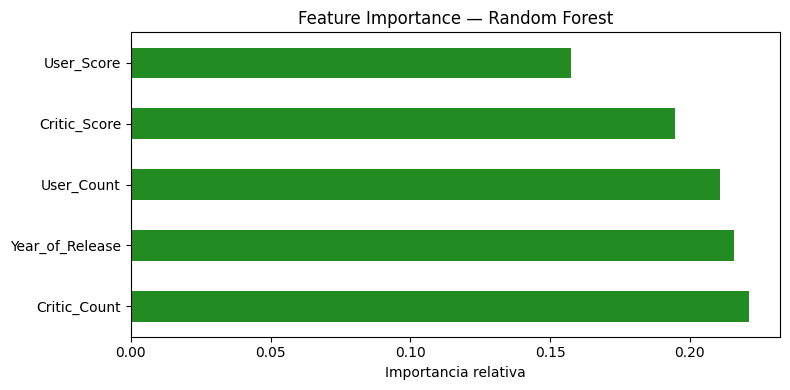

In [ ]:
# --- IMPORTANCIA DE VARIABLES ---
# Muestra qué features el modelo considera más importantes para predecir el éxito
importances = pd.Series(rf.feature_importances_, index=features_reg).sort_values(ascending=False)

importances.plot(kind='barh', color='forestgreen', figsize=(8, 4))
plt.title('Feature Importance — Random Forest')
plt.xlabel('Importancia relativa')
plt.tight_layout()
plt.show()

In [ ]:
# --- EVALUACIÓN: Accuracy y Classification Report ---
# Accuracy: % de predicciones correctas sobre el total
# Precision: de los que predijo como exitosos, cuántos realmente lo eran
# Recall: de los realmente exitosos, cuántos identificó correctamente
# F1-Score: balance entre Precision y Recall
from sklearn.metrics import accuracy_score, classification_report

acc = accuracy_score(y_test_c, y_pred_rf)
print(f'Accuracy: {acc:.4f}\n')

print('=== Classification Report ===')
print(classification_report(y_test_c, y_pred_rf, target_names=['No Exitoso', 'Exitoso']))

Accuracy: 0.6926

=== Classification Report ===
              precision    recall  f1-score   support

  No Exitoso       0.67      0.73      0.70      1621
     Exitoso       0.72      0.66      0.69      1723

    accuracy                           0.69      3344
   macro avg       0.69      0.69      0.69      3344
weighted avg       0.69      0.69      0.69      3344



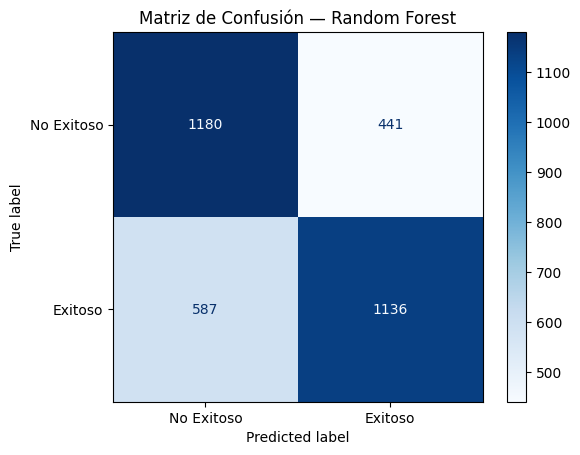

In [ ]:
# --- EVALUACIÓN: Matriz de Confusión ---
# Muestra cuántos juegos clasificó bien y mal en cada clase
# Diagonal principal = predicciones correctas
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm   = confusion_matrix(y_test_c, y_pred_rf)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No Exitoso', 'Exitoso'])
disp.plot(cmap='Blues')
plt.title('Matriz de Confusión — Random Forest')
plt.show()

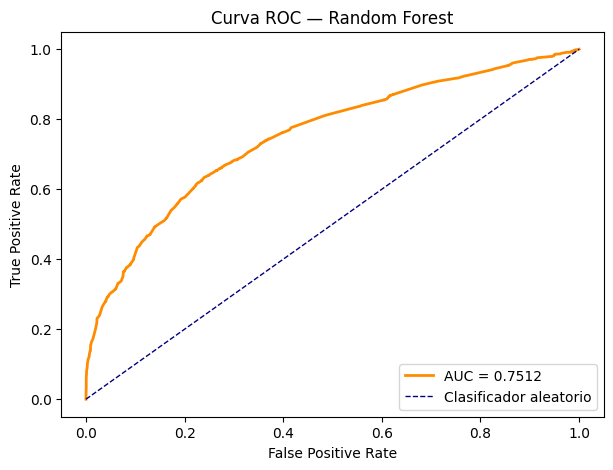

In [ ]:
# --- EVALUACIÓN: Curva ROC y AUC ---
# ROC: muestra la relación entre verdaderos positivos y falsos positivos
# AUC: área bajo la curva. Cercano a 1.0 = modelo excelente, 0.5 = aleatorio
from sklearn.metrics import roc_curve, auc

fpr, tpr, _ = roc_curve(y_test_c, y_prob_rf)
roc_auc     = auc(fpr, tpr)

plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'AUC = {roc_auc:.4f}')
plt.plot([0, 1], [0, 1], color='navy', lw=1, linestyle='--', label='Clasificador aleatorio')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Curva ROC — Random Forest')
plt.legend(loc='lower right')
plt.show()

---
## Modelo 3 — K-Means (Agrupamiento)
**Objetivo:** Agrupar videojuegos en segmentos según sus características numéricas.  
**Por qué K-Means:** Permite descubrir patrones naturales sin necesitar una variable objetivo.

In [ ]:
# --- PREPARACIÓN DE DATOS ---
# Incluimos Global_Sales para que el clustering considere el rendimiento comercial
from sklearn.preprocessing import StandardScaler

features_km = ['Critic_Score', 'User_Score', 'Critic_Count', 'User_Count', 'Year_of_Release', 'Global_Sales']
df_km = df[features_km].dropna().copy()

# Escalamos: K-Means es sensible a la escala de las variables
scaler_km = StandardScaler()
X_km      = scaler_km.fit_transform(df_km)

print(f'Datos para clustering: {X_km.shape}')

Datos para clustering: (16719, 6)


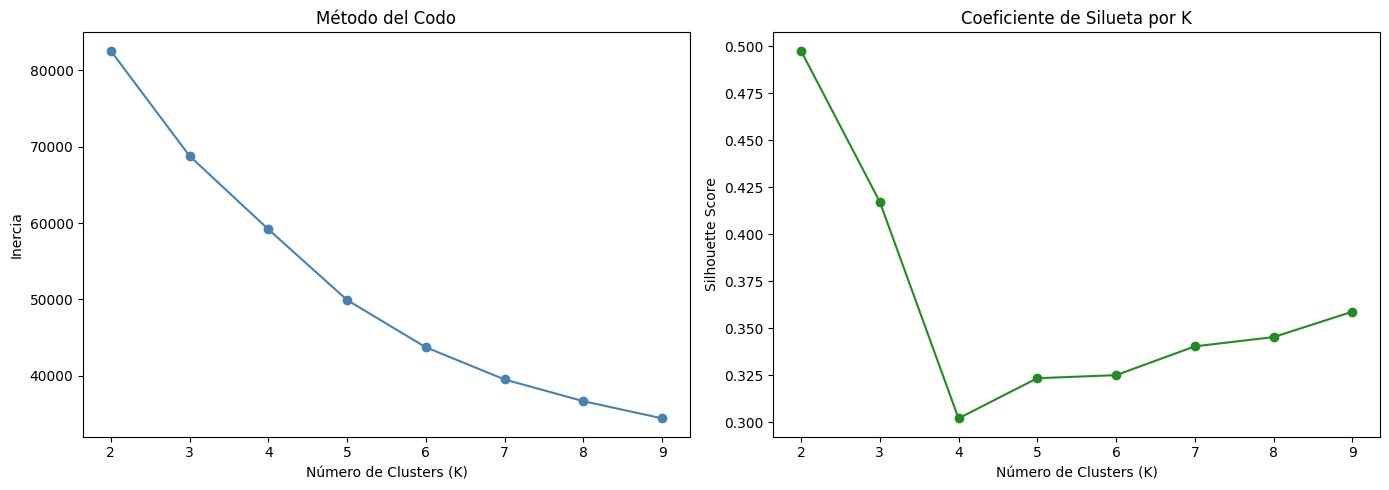

In [ ]:
# --- SELECCIÓN DE K ÓPTIMO ---
# Método del Codo: buscamos el punto donde la inercia deja de bajar significativamente
# Coeficiente de Silueta: elegimos el K con el valor más alto (clusters más separados)
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

inertias    = []
silhouettes = []
K_range     = range(2, 10)

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_km)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(X_km, km.labels_))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(K_range, inertias, marker='o', color='steelblue')
axes[0].set_title('Método del Codo')
axes[0].set_xlabel('Número de Clusters (K)')
axes[0].set_ylabel('Inercia')

axes[1].plot(K_range, silhouettes, marker='o', color='forestgreen')
axes[1].set_title('Coeficiente de Silueta por K')
axes[1].set_xlabel('Número de Clusters (K)')
axes[1].set_ylabel('Silhouette Score')

plt.tight_layout()
plt.show()

In [ ]:
# --- ENTRENAMIENTO CON K ÓPTIMO ---
# Elegimos el K con mayor coeficiente de silueta
k_optimo = list(K_range)[silhouettes.index(max(silhouettes))]
print(f'K óptimo según Silueta: {k_optimo}')

km_final = KMeans(n_clusters=k_optimo, random_state=42, n_init=10)
km_final.fit(X_km)
df_km['Cluster'] = km_final.labels_

print('K-Means entrenado correctamente.')

K óptimo según Silueta: 2
K-Means entrenado correctamente.


In [ ]:
# --- EVALUACIÓN DEL MODELO ---
# El coeficiente de silueta mide qué tan bien separados están los clusters
# Rango: -1 a 1
#   Cercano a  1.0 → clusters compactos y bien separados (ideal)
#   Cercano a  0.0 → clusters solapados
#   Cercano a -1.0 → puntos mal asignados a su cluster
sil_final = silhouette_score(X_km, km_final.labels_)

print('=== Evaluación del Modelo — K-Means ===')
print(f'Coeficiente de Silueta (K={k_optimo}): {sil_final:.4f}')

=== Evaluación del Modelo — K-Means ===
Coeficiente de Silueta (K=2): 0.4977


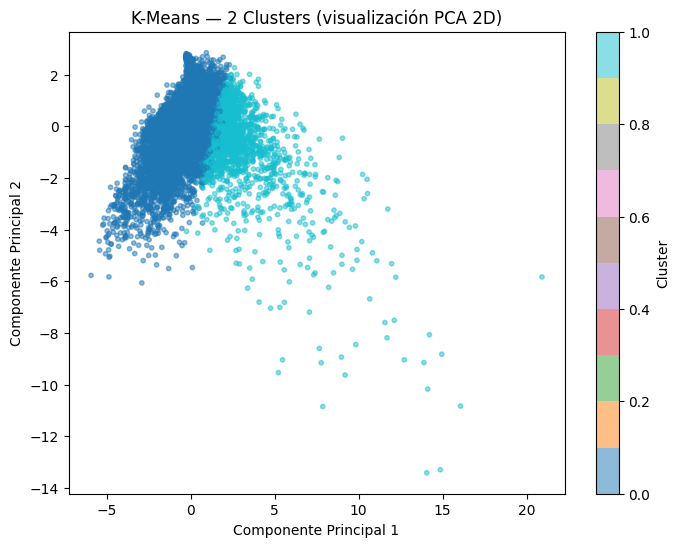

In [ ]:
# --- VISUALIZACIÓN DE CLUSTERS (PCA 2D) ---
# Como los datos tienen 6 dimensiones, usamos PCA para reducirlos a 2 y poder graficarlos
from sklearn.decomposition import PCA

pca   = PCA(n_components=2)
X_pca = pca.fit_transform(X_km)

plt.figure(figsize=(8, 6))
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1],
                      c=df_km['Cluster'], cmap='tab10', alpha=0.5, s=10)
plt.colorbar(scatter, label='Cluster')
plt.title(f'K-Means — {k_optimo} Clusters (visualización PCA 2D)')
plt.xlabel('Componente Principal 1')
plt.ylabel('Componente Principal 2')
plt.show()

In [ ]:
# --- PERFIL DE CADA CLUSTER ---
# Muestra el promedio de cada variable por cluster
# Permite entender qué tipo de juego representa cada grupo
print('=== Perfil promedio por Cluster ===')
print(df_km.groupby('Cluster').mean().round(2))

=== Perfil promedio por Cluster ===
         Critic_Score  User_Score  Critic_Count  User_Count  Year_of_Release  \
Cluster                                                                        
0               68.74        7.29         20.28       32.65          2006.25   
1               81.68        7.74         54.31      585.24          2008.72   

         Global_Sales  
Cluster                
0                0.35  
1                2.23  


In [ ]:
# --- EXPORTACIÓN PARA POWER BI ---
# Usamos directamente X_test.index / X_test_c.index
# que son los índices REALES que train_test_split eligió para el test

df_export = df.copy()

# Ridge: usamos X_test.index (los índices reales del set de prueba)
df_export.loc[X_test.index, 'ventas_predichas'] = y_pred_ridge

# Random Forest: igual, X_test_c.index tiene los índices correctos
df_export.loc[X_test_c.index, 'exito_real']     = y_test_c.values
df_export.loc[X_test_c.index, 'exito_predicho'] = y_pred_rf
df_export.loc[X_test_c.index, 'prob_exito']     = y_prob_rf

# K-Means: df_km.index ya es correcto porque no hubo train/test split
df_export.loc[df_km.index, 'Cluster'] = df_km['Cluster'].values

# Exportar
from google.colab import drive
drive.mount('/content/drive')

df_export.to_csv('/content/drive/MyDrive/videogames_resultadoscorrectos.csv', index=False,
                 decimal=',',
                 sep=';')
print(f'CSV exportado: {len(df_export)} filas, {len(df_export.columns)} columnas')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
CSV exportado: 16719 filas, 21 columnas


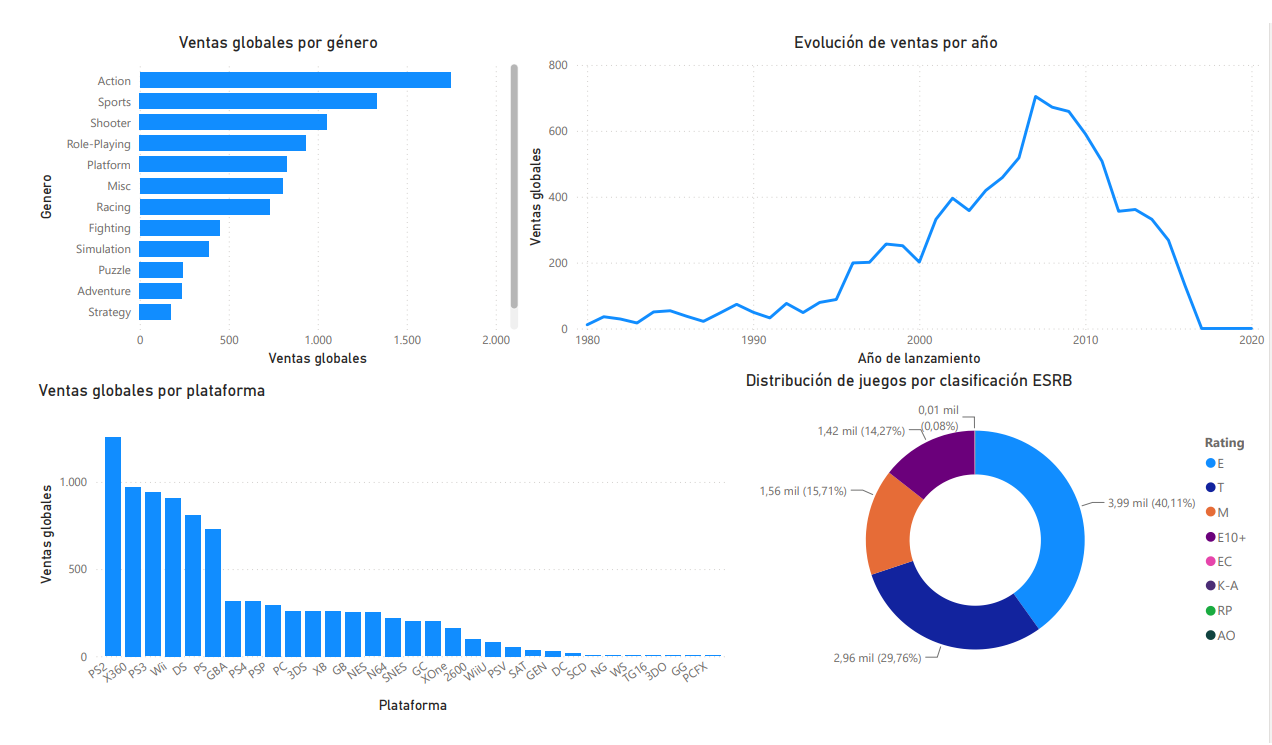

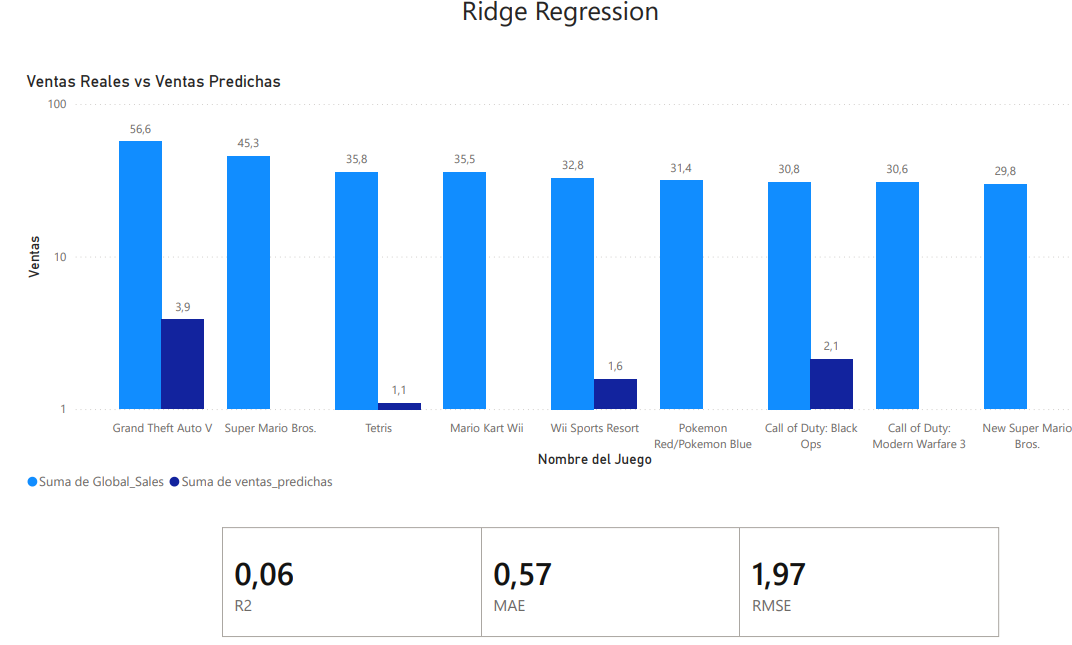

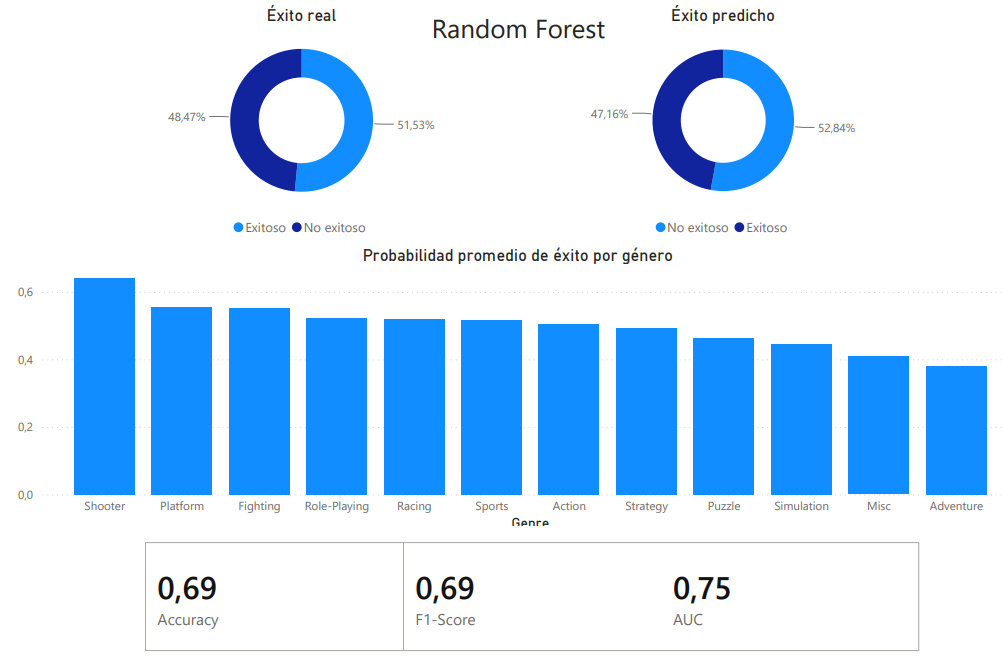

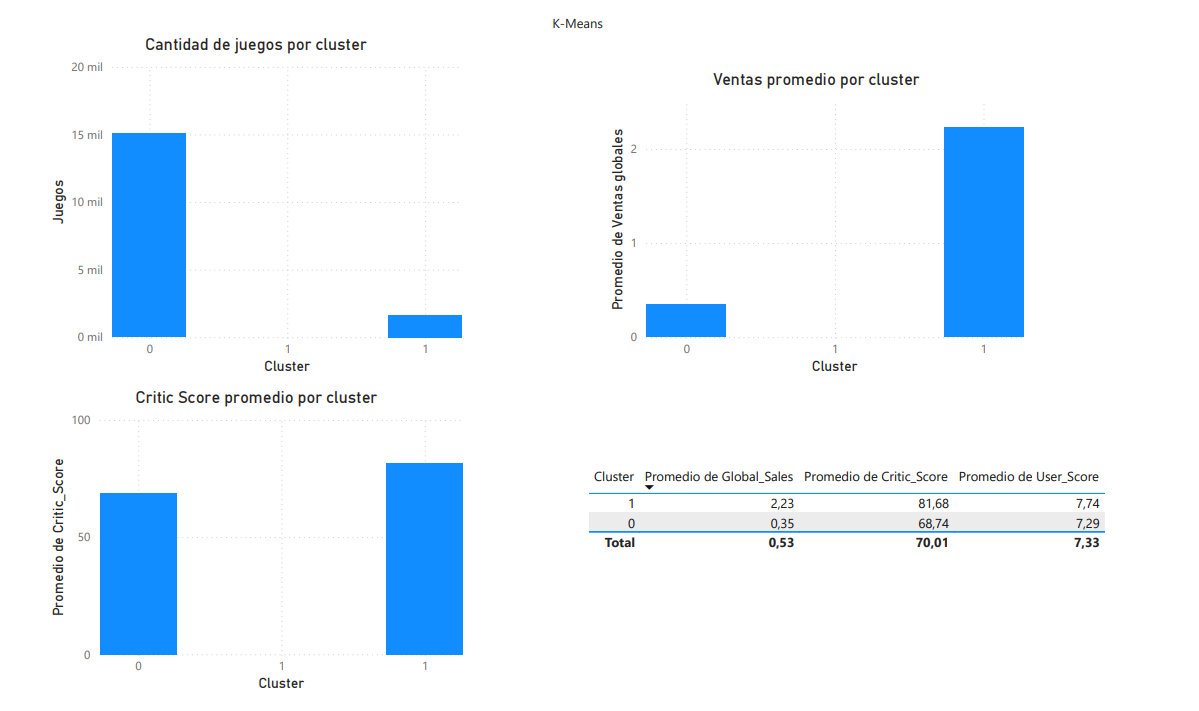